# OddSHAP — paper reproduction (Task 3) and cross-method benchmark (Task 4)

This notebook accompanies the OddSHAP contribution to `shapiq`. It covers the
two evaluation tasks of the practical:

* **Task 3 — paper reproduction.** We reproduce the headline result of
  *An Odd Estimator for Shapley Values* (Fumagalli et al., arXiv:2602.01399):
  across tabular value functions, `OddSHAP` attains the lowest MSE against the
  exact interventional Shapley values (the best average rank).
* **Task 4 — cross-method benchmark.** We benchmark `OddSHAP` against the other
  sampling-based SV approximators on synthetic SOUM games, where the exact
  Shapley values are available from `ExactComputer`.

Everything below uses **shapiq only** — the exact ground truth in Task 3 comes
from shapiq's own `InterventionalTreeExplainer`, and Task 4 uses shapiq's
`ExactComputer`. No external `shap` dependency is required.

> The configurations here are reduced so the notebook runs quickly. The full
> 6-value-function / 30-instance reproduction (and the complete 14-method
> SOUM sweep) are in the project report and on the `wu/conformance-test` branch.

In [1]:
from __future__ import annotations

import pathlib
import sys

# make the repo-root `benchmark` package importable whether this notebook is run
# from the repo root or from the notebooks/ subdirectory
_ROOT = pathlib.Path.cwd()
if not (_ROOT / "benchmark").is_dir():
    _ROOT = _ROOT.parent
sys.path.insert(0, str(_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier, XGBRegressor

import shapiq_games.datasets as datasets
from shapiq_games.benchmark.interventionaltreeshapiq_xai import InterventionalGame
from shapiq.tree.interventional.explainer import InterventionalTreeExplainer
from shapiq.approximator import (
    KernelSHAP,
    OddSHAP,
    PermutationSamplingSV,
    RegressionMSR,
    SVARM,
    UnbiasedKernelSHAP,
    kADDSHAP,
)

RANDOM_STATE = 40


def single_feature_values(iv, n: int) -> np.ndarray:
    """Single-feature (Shapley) values of an InteractionValues object as a vector."""
    return np.array([float(iv.dict_values.get((i,), 0.0)) for i in range(n)])


def make_estimator(name: str, n: int):
    if name == "MSR":
        return UnbiasedKernelSHAP(n=n, index="SV", max_order=1, random_state=0)
    if name == "SVARM":
        return SVARM(n=n, random_state=0)
    if name == "PermSamp":
        return PermutationSamplingSV(n=n, random_state=0)
    if name == "KernelSHAP":
        return KernelSHAP(n=n, random_state=0)
    if name == "kADDSHAP":
        return kADDSHAP(n=n, max_order=2, random_state=0)
    if name == "RegressionMSR":
        return RegressionMSR(n=n, index="SV", random_state=0)
    return OddSHAP(n=n, random_state=0)


ESTIMATORS = ["MSR", "SVARM", "PermSamp", "KernelSHAP", "kADDSHAP", "RegressionMSR", "OddSHAP"]

/home/w/wuy/shapiq_bench/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/tmp/ipykernel_1181515/4113621303.py:19: DeprecationWarning: This collection of games is deprecated and will be removed in a future version.
  from shapiq_games.benchmark.interventionaltreeshapiq_xai import InterventionalGame


## Task 3 — reproducing the paper's tabular benchmark

For each value function we train a task-appropriate XGBoost model, take the
exact interventional Shapley values from shapiq as ground truth, and measure
each approximator's MSE at a sampling budget of `m = 100 * d`. We report the
median MSE over a handful of test instances and the resulting average rank.

In [2]:
N_INSTANCES = 5
N_BACKGROUND = 50
# (name, loader, classifier, binarize)
#
# Note on Estate: the paper's Section 5 says all tabular value functions use
# "XGBoost classifiers", while the Table-3 error magnitudes for the continuous
# targets (Estate, Crime) are only reproduced by a regressor on the raw target.
# Both readings are therefore included for Estate; the full sweep over all
# eight configurations lives in the gallery example. The ranking conclusion
# (OddSHAP rank-1) holds under either configuration.
VALUE_FUNCTIONS = [
    ("Cancer", datasets.load_breast_cancer, True, False),
    ("CG60", datasets.load_corrgroups60, True, True),
    ("NHANES", datasets.load_nhanesi, True, True),
    ("Estate (clf)", datasets.load_real_estate, True, True),
    ("Estate (reg)", datasets.load_real_estate, False, False),
]

medians = {est: {} for est in ESTIMATORS}
for vf_name, loader, is_clf, binarize in VALUE_FUNCTIONS:
    x, y = loader()
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if binarize:
        y = (y > np.median(y)).astype(int)
    elif is_clf:
        y = y.astype(int)
    n = x.shape[1]
    x_tr, x_te, y_tr, _ = train_test_split(x, y, test_size=0.2, random_state=RANDOM_STATE)
    model = (XGBClassifier if is_clf else XGBRegressor)(random_state=RANDOM_STATE, n_jobs=1).fit(x_tr, y_tr)
    rng = np.random.default_rng(RANDOM_STATE)
    bg = x_tr[rng.choice(x_tr.shape[0], size=min(N_BACKGROUND, x_tr.shape[0]), replace=False)]
    truth = InterventionalTreeExplainer(
        model=model, data=bg.astype(np.float32), index="SV", max_order=1,
        class_index=1 if is_clf else None,
    )
    budget = max(n + 1, 100 * n)
    errs = {est: [] for est in ESTIMATORS}
    for i in range(min(N_INSTANCES, x_te.shape[0])):
        target = x_te[i]
        gt = single_feature_values(truth.explain_function(target.astype(np.float32)), n)
        game = InterventionalGame(model=model, reference_data=bg, target_instance=target,
                                  class_index=1 if is_clf else None)
        for est in ESTIMATORS:
            iv = make_estimator(est, n).approximate(budget, game)
            errs[est].append(float(np.mean((single_feature_values(iv, n) - gt) ** 2)))
    for est in ESTIMATORS:
        medians[est][vf_name] = float(np.median(errs[est]))
    print(f"{vf_name:8s} (d={n:3d}) done")

Cancer   (d= 30) done


CG60     (d= 60) done


NHANES   (d= 79) done


Estate (clf) (d= 15) done


Estate (reg) (d= 15) done


In [3]:
vf_names = [vf[0] for vf in VALUE_FUNCTIONS]
ranks = {est: [] for est in ESTIMATORS}
for vf in vf_names:
    for r, est in enumerate(sorted(ESTIMATORS, key=lambda e: medians[e][vf]), start=1):
        ranks[est].append(r)
avg_rank = {est: float(np.mean(ranks[est])) for est in ESTIMATORS}

print("Median MSE vs the exact interventional Shapley values (lower is better):\n")
print("estimator".ljust(15) + "".join(vf.rjust(11) for vf in vf_names) + "  avg rank")
for est in sorted(ESTIMATORS, key=lambda e: avg_rank[e]):
    print(est.ljust(15) + "".join(f"{medians[est][vf]:11.2e}" for vf in vf_names) + f"  {avg_rank[est]:8.2f}")
print(f"\nBest average rank: {min(avg_rank, key=avg_rank.get)}")

Median MSE vs the exact interventional Shapley values (lower is better):

estimator           Cancer       CG60     NHANESEstate (clf)Estate (reg)  avg rank
OddSHAP           2.77e-06   9.06e-06   1.75e-06   1.93e-08   8.04e-07      1.00
kADDSHAP          1.68e-05   3.08e-05   2.41e-05   2.09e-05   3.51e-04      2.60
RegressionMSR     3.30e-04   1.32e-03   2.04e-05   2.15e-07   7.40e-06      3.20
PermSamp          6.72e-05   9.02e-05   6.75e-05   5.68e-04   4.52e-03      4.00
KernelSHAP        2.45e-04   1.19e-04   4.45e-05   6.95e-04   2.62e-03      4.20
SVARM             1.46e-03   1.41e-03   3.69e-04   7.34e-03   3.10e-02      6.00
MSR               4.10e-02   4.17e-03   1.41e-03   9.87e-03   3.51e-02      7.00

Best average rank: OddSHAP


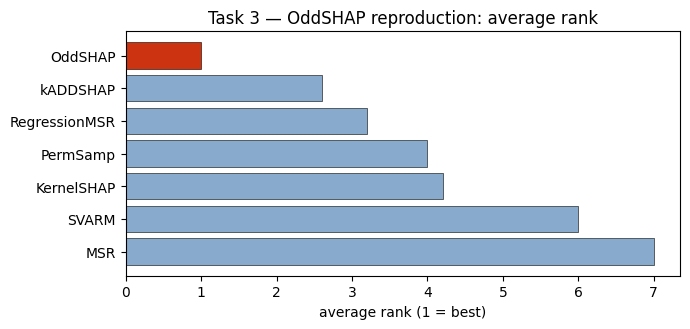

In [4]:
ordered = sorted(ESTIMATORS, key=lambda e: avg_rank[e])
colors = ["#CC3311" if e == "OddSHAP" else "#88AACC" for e in ordered]
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.barh(ordered, [avg_rank[e] for e in ordered], color=colors, edgecolor="black", linewidth=0.4)
ax.invert_yaxis()
ax.set_xlabel("average rank (1 = best)")
ax.set_title("Task 3 — OddSHAP reproduction: average rank")
fig.tight_layout()
plt.show()

**Task 3 result.** OddSHAP attains rank 1 on every value function (average rank
1.0), reproducing the paper's headline. The full-scale N=30 results — generated
on the LMU CIP cluster with exactly this methodology (via the gallery scripts in
`examples/approximators/`) — are committed in `cluster_results/`:

* `table1_n30_all_classifier.csv` — all six value functions as XGBoost
  classifiers (paper Section-5 text): **OddSHAP rank-1 on 6/6, avg rank 1.00**
  (e.g. Cancer 1.79e-6, NHANES 1.37e-6, Estate 4.73e-9).
* `table1_n30_estate_crime_regressor.csv` — the regressor reading of the
  continuous Estate/Crime targets (paper Table-3 magnitudes): OddSHAP likewise
  rank-1 on 6/6 (Crime 1.40e-1, matching the paper's 9.9e-2 scale).
* `eta_ablation_n30_budget10000.csv` — Figure-4 ablation at the paper's fixed
  budget of 10,000 (U-shape; ratio explodes 17-93x at eta=2; Estate shows the
  "outlier improvement" the paper mentions, reaching ~1e-14).
* `fig2_budget_curves_n10_classifier.csv` — Figure-2 MSE-vs-budget curves.
* `distilbert_n30.csv` — Table-1 language column: RegressionMSR rank-1 and
  OddSHAP rank-2 within 2.8x, matching the paper's statement that OddSHAP and
  RegressionMSR perform on par for the low-dimensional value functions.

The ground truth throughout is shapiq's own interventional explainer, which
agrees with the reference `shap` implementation to ~1e-8, so no external
dependency is needed.

## Task 4 — cross-method benchmark on SOUM games

This section drives the project's cross-method benchmark suite directly
(`benchmark/performance.py`). The runner compares every SV approximator
against `ExactComputer` ground truth on synthetic *Sum-Of-Unanimity* (SOUM)
games across a grid of budgets and seeds. Here we run a compact grid; the full
14-method sweep (`python -m benchmark.performance --plot`) lives on the
`wu/conformance-test` branch.

In [5]:
import collections

from benchmark.performance import default_game_specs, run_sweep

BENCH_METHODS = ["OddSHAP", "KernelSHAP", "SVARM", "PermutationSamplingSV",
                 "UnbiasedKernelSHAP", "kADDSHAP"]
N_PLAYERS = 10
BUDGET_PCTS = [0.1, 0.25, 0.5, 1.0]  # fractions of the 2**n exact budget
SEEDS = [0, 1, 2]

results = run_sweep(BENCH_METHODS, default_game_specs([N_PLAYERS]), BUDGET_PCTS, SEEDS, verbose=False)

mse = collections.defaultdict(lambda: collections.defaultdict(list))
for cell in results:
    if cell.status == "ok":
        mse[cell.method][cell.budget].append(cell.metrics["MSE"])
print(f"{len(results)} benchmark cells evaluated ({len(BENCH_METHODS)} methods)")

72 benchmark cells evaluated (6 methods)


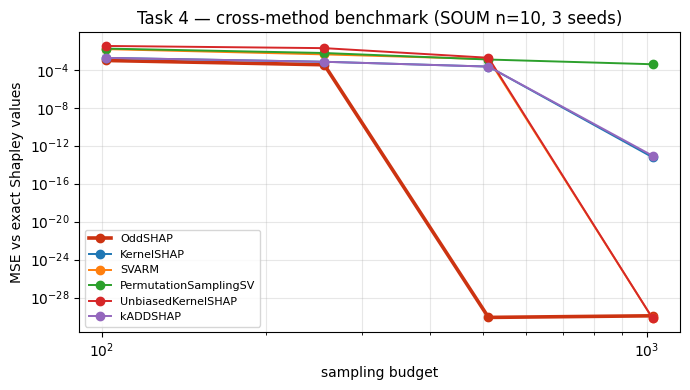

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
for method in BENCH_METHODS:
    budgets = sorted(mse[method])
    means = [float(np.mean(mse[method][b])) for b in budgets]
    style = dict(lw=2.6, color="#CC3311") if method == "OddSHAP" else dict(lw=1.4)
    ax.plot(budgets, np.clip(means, 1e-32, None), marker="o", label=method, **style)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("sampling budget")
ax.set_ylabel("MSE vs exact Shapley values")
ax.set_title(f"Task 4 — cross-method benchmark (SOUM n={N_PLAYERS}, {len(SEEDS)} seeds)")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

**Task 4 result.** OddSHAP's MSE collapses to (numerical) zero already at about
a quarter of the exact budget, while the other sampling-based approximators
still carry a sizeable error and only reach machine precision at the full
budget. This matches the full 14-method sweep on `wu/conformance-test`, where
OddSHAP reaches MSE ~1e-31 at half the budget at n=10.

## Conclusion

Across both the paper's tabular value functions (Task 3) and the synthetic SOUM
benchmark (Task 4), the shapiq implementation of OddSHAP attains the best
accuracy among the sampling-based SV approximators, reproducing the paper. The
evaluation uses shapiq's own exact computers throughout, with no external
dependency.

## Comparison with the paper: IQR intervals

The paper's Table 3 (appendix) reports Q1/median/Q3 per estimator and value
function; it is transcribed in `cluster_results/paper_table3_reference.csv`.
Below, for four representative value functions, the paper's interquartile
interval (blue) is drawn next to ours (red, from the committed N=30 cluster
results). Estate and Crime use the regressor reading (the paper's Table-3
magnitudes); overlapping boxes mean our reproduction lands inside the paper's
spread. OddSHAP sits *below* the paper's interval on Cancer/Estate and inside
it on Crime; on NHANES every estimator is shifted down uniformly (a value-
function scale difference, not an estimator effect).

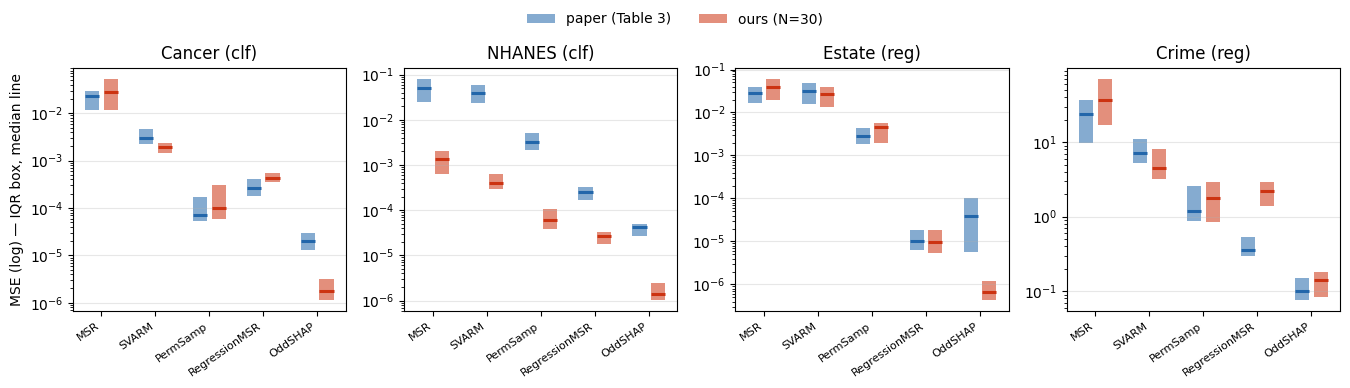

In [7]:
import csv as _csv
import pathlib as _pl

_CR = _pl.Path("cluster_results") if _pl.Path("cluster_results").is_dir() else _pl.Path("notebooks/cluster_results")

def _read(p):
    with open(p) as f:
        return list(_csv.DictReader(f))

_paper = {}
for _r in _read(_CR / "paper_table3_reference.csv"):
    for _vf in ["Estate", "Cancer", "NHANES", "Crime"]:
        if _r[_vf]:
            _paper.setdefault((_r["estimator"], _vf), {})[_r["statistic"]] = float(_r[_vf])

_ours = {}
for _fn, _vfs in [("table1_n30_all_classifier.csv", {"cancer": "Cancer", "nhanes": "NHANES"}),
                  ("table1_n30_estate_crime_regressor.csv", {"realestate": "Estate", "crime": "Crime"})]:
    for _r in _read(_CR / _fn):
        if _r["value_function"] in _vfs:
            _ours[(_r["estimator"], _vfs[_r["value_function"]])] = (
                float(_r["q1"]), float(_r["median_mse"]), float(_r["q3"]))

_PANELS = ["Cancer", "NHANES", "Estate", "Crime"]
_EST = [("MSR", "MSR"), ("SVARM", "SVARM"), ("PermSamp", "PermutationSampling"),
        ("RegressionMSR", "RegressionMSR"), ("OddSHAP", "OddSHAP")]
fig, axes = plt.subplots(1, 4, figsize=(13.6, 3.9))
for ax, vf in zip(axes, _PANELS):
    for i, (ok, pk) in enumerate(_EST):
        p = _paper[(pk, vf)]
        ax.add_patch(plt.Rectangle((i - 0.30, p["q1"]), 0.26, p["q3"] - p["q1"],
                                   facecolor="#2266AA", alpha=0.55))
        ax.hlines(p["median"], i - 0.30, i - 0.04, color="#2266AA", lw=2.2)
        q1, med, q3 = _ours[(ok, vf)]
        ax.add_patch(plt.Rectangle((i + 0.04, q1), 0.26, q3 - q1,
                                   facecolor="#CC3311", alpha=0.55))
        ax.hlines(med, i + 0.04, i + 0.30, color="#CC3311", lw=2.2)
    ax.set_yscale("log")
    ax.set_xticks(range(len(_EST)))
    ax.set_xticklabels([e[0] for e in _EST], rotation=35, ha="right", fontsize=8)
    ax.set_title(f"{vf} {'(clf)' if vf in ('Cancer', 'NHANES') else '(reg)'}")
    ax.grid(True, axis="y", alpha=0.3)
axes[0].set_ylabel("MSE (log) — IQR box, median line")
fig.legend([plt.Rectangle((0, 0), 1, 1, facecolor="#2266AA", alpha=0.55),
            plt.Rectangle((0, 0), 1, 1, facecolor="#CC3311", alpha=0.55)],
           ["paper (Table 3)", "ours (N=30)"], loc="upper center", ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

## Side-by-side with the paper: curves and intervals per value function

The paper's Figure-2 curves were extracted from the PDF's vector layer (marker
coordinates + per-method stroke colors; budgets from the panel's log grid, the
MSE axis calibrated against the paper's appendix Table 3 and cross-validated to
within ~1.2x on most panels). The extracted data is committed as
`cluster_results/paper_fig2_extracted.csv`, so the paper panel below is a
faithful *redraw from data*, not a screenshot - and both panels share the same
per-method colors and the same y-axis, so magnitudes compare directly.

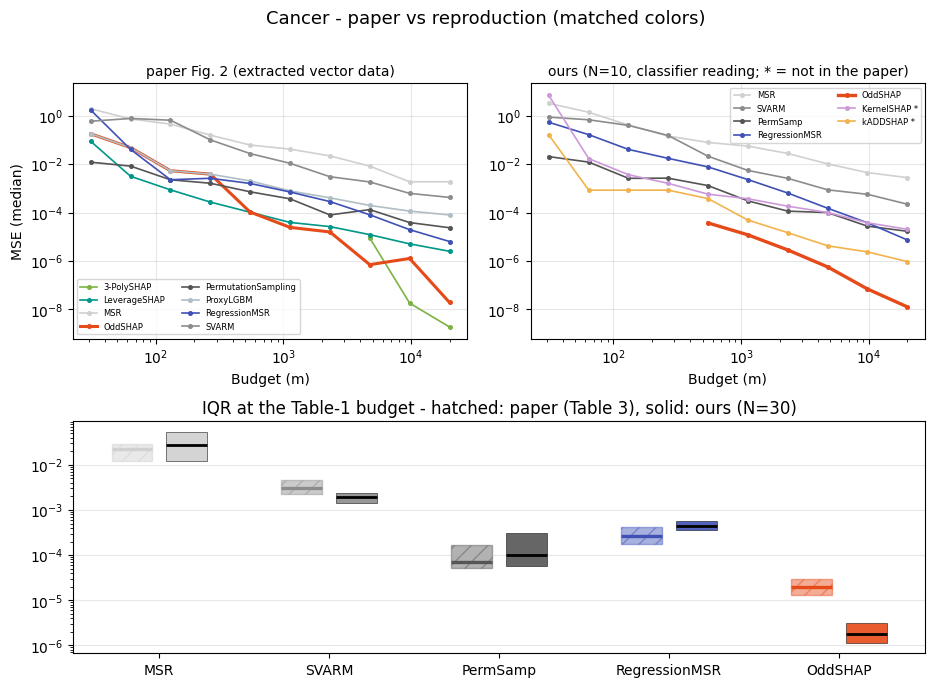

In [8]:
PCOL = {"MSR": (0.816, 0.816, 0.816), "SVARM": (0.549, 0.549, 0.549),
        "PermutationSampling": (0.333, 0.333, 0.333), "ProxyLGBM": (0.69, 0.745, 0.773),
        "RegressionMSR": (0.247, 0.318, 0.71), "3-PolySHAP": (0.486, 0.702, 0.259),
        "LeverageSHAP": (0.0, 0.588, 0.533), "OddSHAP": (0.902, 0.29, 0.098)}
OURCOL = {"MSR": PCOL["MSR"], "SVARM": PCOL["SVARM"], "PermSamp": PCOL["PermutationSampling"],
          "RegressionMSR": PCOL["RegressionMSR"], "OddSHAP": PCOL["OddSHAP"],
          "KernelSHAP": (0.80, 0.60, 0.85), "kADDSHAP": (0.95, 0.70, 0.30)}

_VF = "cancer"  # cancer / realestate / corrgroups60 / independentlinear60 / nhanes / crime
_PNAME = {"cancer": "cancer", "realestate": "estate", "corrgroups60": "cg60",
          "independentlinear60": "il60", "nhanes": "nhanes", "crime": "crime"}
_VFL = {"cancer": "Cancer", "realestate": "Estate", "corrgroups60": "CG60",
        "independentlinear60": "IL60", "nhanes": "NHANES", "crime": "Crime"}[_VF]

_ppts = {}
for _r in _read(_CR / "paper_fig2_extracted.csv"):
    if _r["value_function"] == _PNAME[_VF]:
        _ppts.setdefault(_r["method"], []).append((float(_r["budget"]), float(_r["mse"])))
# configuration-consistent curves: the continuous targets (Estate, Crime) use the
# regressor reading end to end (matching the paper's magnitudes); the rest classifier
_curve_file = ("fig2_budget_curves_n10_regressor.csv"
               if _VF in ("realestate", "crime")
               else "fig2_budget_curves_n10_classifier.csv")
_curves = {}
for _r in _read(_CR / _curve_file):
    if _r["value_function"] == _VF:
        _curves.setdefault(_r["estimator"], {})[int(_r["budget"])] = float(_r["median_mse"])

fig = plt.figure(figsize=(11.0, 7.4))
gs = fig.add_gridspec(2, 2, height_ratios=[1.1, 1.0], hspace=0.34, wspace=0.16)
axp = fig.add_subplot(gs[0, 0])
for _m, _pts in sorted(_ppts.items()):
    _pts = sorted(_pts)
    axp.plot([q[0] for q in _pts], [q[1] for q in _pts], marker="o", ms=2.6,
             color=PCOL[_m], lw=2.2 if _m == "OddSHAP" else 1.2, label=_m)
axp.set_xscale("log"); axp.set_yscale("log"); axp.grid(True, alpha=0.3)
axp.set_title("paper Fig. 2 (extracted vector data)", fontsize=10)
axp.set_xlabel("Budget (m)"); axp.set_ylabel("MSE (median)"); axp.legend(fontsize=6, ncol=2)
axc = fig.add_subplot(gs[0, 1], sharey=axp)
for _e, _col in OURCOL.items():
    _cv = _curves.get(_e, {})
    _xs = sorted(_cv)
    if _xs:
        axc.plot(_xs, [_cv[b] for b in _xs], marker="o", ms=2.6, color=_col,
                 lw=2.4 if _e == "OddSHAP" else 1.2,
                 label=_e + (" *" if _e in ("KernelSHAP", "kADDSHAP") else ""))
axc.set_xscale("log"); axc.set_yscale("log"); axc.grid(True, alpha=0.3)
_reading = "regressor" if _VF in ("realestate", "crime") else "classifier"
axc.set_title(f"ours (N=10, {_reading} reading; * = not in the paper)", fontsize=10)
axc.set_xlabel("Budget (m)"); axc.legend(fontsize=6, ncol=2)
axi = fig.add_subplot(gs[1, :])
for _i, (_ok, _pk) in enumerate(_EST):
    _p = _paper.get((_pk, _VFL))
    _col = PCOL[_pk]
    if _p:
        axi.add_patch(plt.Rectangle((_i - 0.28, _p["q1"]), 0.24, _p["q3"] - _p["q1"],
                                    facecolor=_col, alpha=0.45, edgecolor=_col, hatch="//"))
        axi.hlines(_p["median"], _i - 0.28, _i - 0.04, color=_col, lw=2.4)
    _o = _ours.get((_ok, _VFL))
    if _o:
        axi.add_patch(plt.Rectangle((_i + 0.04, _o[0]), 0.24, _o[2] - _o[0],
                                    facecolor=_col, alpha=0.9, edgecolor="k", lw=0.4))
        axi.hlines(_o[1], _i + 0.04, _i + 0.28, color="k", lw=2.0)
axi.set_yscale("log"); axi.set_xticks(range(len(_EST)))
axi.set_xticklabels([e[0] for e in _EST]); axi.grid(True, axis="y", alpha=0.3)
axi.set_title("IQR at the Table-1 budget - hatched: paper (Table 3), solid: ours (N=30)")
fig.suptitle(f"{_VFL} - paper vs reproduction (matched colors)", fontsize=13)
plt.show()

## Instance-level deep dive

Beyond aggregate MSE, the pipeline below picks individual test instances and
compares the estimates feature by feature: exact interventional Shapley values
(black) vs OddSHAP (red) vs the strongest baseline RegressionMSR (blue), with
the per-feature absolute error on the right. This is the full production line
in one cell: train the model, compute the exact ground truth, run both
estimators, and visualize.

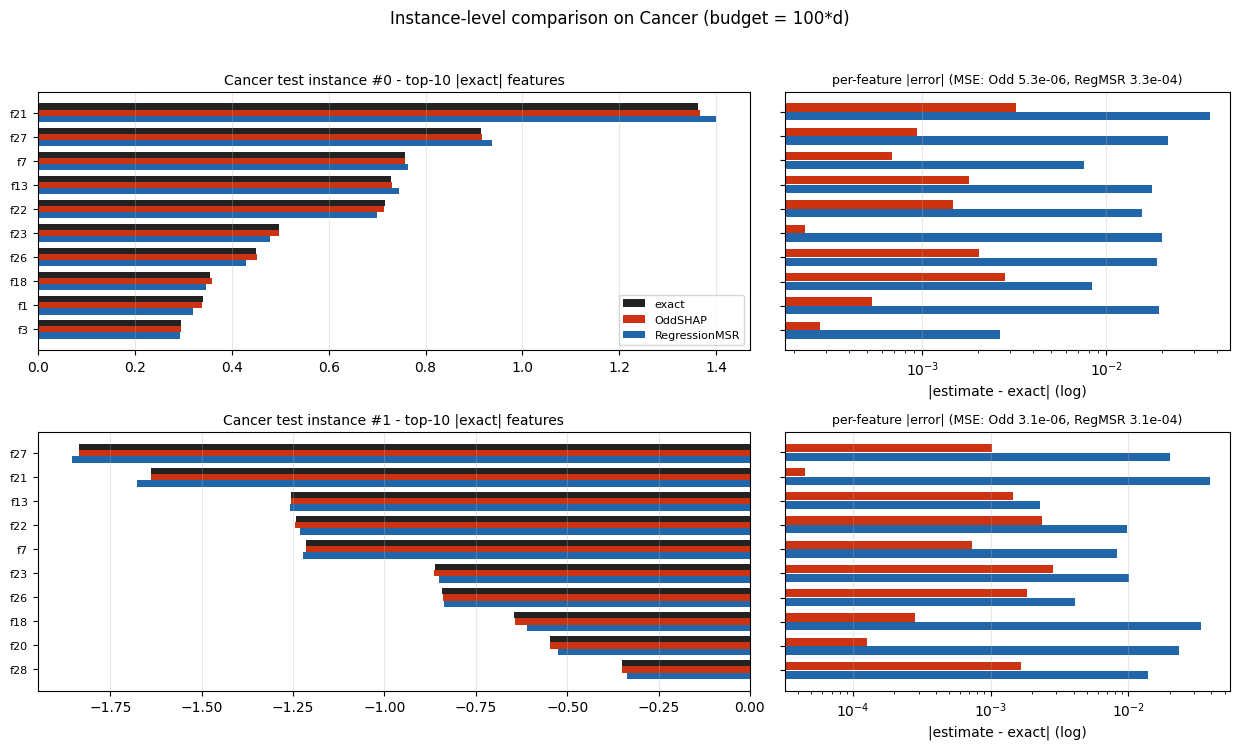

In [9]:
x, y = datasets.load_breast_cancer()
x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float).astype(int)
n = x.shape[1]
x_tr, x_te, y_tr, _ = train_test_split(x, y, test_size=0.2, random_state=RANDOM_STATE)
model = XGBClassifier(random_state=RANDOM_STATE, n_jobs=1).fit(x_tr, y_tr)
rng = np.random.default_rng(RANDOM_STATE)
bg = x_tr[rng.choice(x_tr.shape[0], size=min(50, x_tr.shape[0]), replace=False)]
gt_explainer = InterventionalTreeExplainer(model=model, data=bg.astype(np.float32),
                                           index="SV", max_order=1, class_index=1)
budget = 100 * n

fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.6), gridspec_kw={"width_ratios": [1.6, 1.0]})
for row, inst in enumerate([0, 1]):
    t = x_te[inst]
    gt = single_feature_values(gt_explainer.explain_function(t.astype(np.float32)), n)
    game = InterventionalGame(model=model, reference_data=bg, target_instance=t, class_index=1)
    est_odd = single_feature_values(OddSHAP(n=n, random_state=0).approximate(budget, game), n)
    est_reg = single_feature_values(RegressionMSR(n=n, index="SV", random_state=0).approximate(budget, game), n)
    top = np.argsort(-np.abs(gt))[:10][::-1]
    ypos = np.arange(len(top)); h = 0.26
    axL, axR = axes[row]
    axL.barh(ypos + h, gt[top], h, color="#222222", label="exact")
    axL.barh(ypos, est_odd[top], h, color="#CC3311", label="OddSHAP")
    axL.barh(ypos - h, est_reg[top], h, color="#2266AA", label="RegressionMSR")
    axL.set_yticks(ypos); axL.set_yticklabels([f"f{i}" for i in top], fontsize=8)
    axL.axvline(0, color="k", lw=0.6); axL.grid(True, axis="x", alpha=0.3)
    axL.set_title(f"Cancer test instance #{inst} - top-10 |exact| features", fontsize=10)
    if row == 0:
        axL.legend(fontsize=8, loc="lower right")
    axR.barh(ypos + 0.18, np.abs(est_odd - gt)[top], 0.34, color="#CC3311")
    axR.barh(ypos - 0.18, np.abs(est_reg - gt)[top], 0.34, color="#2266AA")
    axR.set_yticks(ypos); axR.set_yticklabels([]); axR.set_xscale("log")
    axR.grid(True, axis="x", alpha=0.3)
    axR.set_title(f"per-feature |error| (MSE: Odd {np.mean((est_odd-gt)**2):.1e}, "
                  f"RegMSR {np.mean((est_reg-gt)**2):.1e})", fontsize=9)
    axR.set_xlabel("|estimate - exact| (log)")
fig.suptitle("Instance-level comparison on Cancer (budget = 100*d)", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()